In [7]:
# -------------------------- 1️⃣ IMPORTS --------------------------
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [8]:
# -------------------------- 2️⃣ DATASET PATHS --------------------------
dataset_dirs = {
    'Benign': r"D:\NEW\AUGMENTED DATASET\Benign",
    'Malignant': r"D:\NEW\AUGMENTED DATASET\Malignant",
    'Normal': r"D:\NEW\AUGMENTED DATASET\Normal"
}

filepaths, labels = [], []
for label, folder in dataset_dirs.items():
    if not os.path.exists(folder):
        print(f"⚠️ Directory not found: {folder}")
        continue
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            filepaths.append(os.path.join(folder, filename))
            labels.append(label)

Lung_df = pd.DataFrame({'filepath': filepaths, 'label': labels})
Lung_df = Lung_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Dataset loaded with {len(Lung_df)} images")
print(Lung_df['label'].value_counts())


✅ Dataset loaded with 11271 images
label
Malignant    3927
Normal       3744
Benign       3600
Name: count, dtype: int64


In [9]:
# -------------------------- 3️⃣ SPLIT DATASET --------------------------
train_val_df, test_df = train_test_split(
    Lung_df, test_size=0.2, stratify=Lung_df['label'], random_state=42
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['label'], random_state=42
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")


Training samples: 7212
Validation samples: 1804
Test samples: 2255


In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224,224), color_mode='rgb',  # <-- important
    class_mode='categorical', batch_size=16, shuffle=True
)

val_generator = test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224,224), color_mode='rgb',
    class_mode='categorical', batch_size=16, shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(224,224), color_mode='rgb',
    class_mode='categorical', batch_size=16, shuffle=False
)


Found 7212 validated image filenames belonging to 3 classes.
Found 1804 validated image filenames belonging to 3 classes.
Found 2255 validated image filenames belonging to 3 classes.


In [11]:
# -------------------------- 5️⃣ CLASS WEIGHTS --------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)


Class weights: {0: np.float64(1.0434027777777777), 1: np.float64(0.9570063694267515), 2: np.float64(1.003338898163606)}


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# -------------------------- 6️⃣ CALLBACKS --------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_densenet_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks_list = [early_stop, checkpoint, reduce_lr]


In [15]:
# -------------------------- 7️⃣ MODEL DEFINITION --------------------------
def create_transfer_model_ctscan_densenet(input_shape=(224,224,3), num_classes=3, base_trainable=False):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = base_trainable
    
    x = GlobalAveragePooling2D()(base_model.output)
    
    x = Dense(512, kernel_regularizer=l2(0.001))(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = Dense(256, kernel_regularizer=l2(0.001))(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    output = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    return model

transfer_model = create_transfer_model_ctscan_densenet(base_trainable=False)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=1000,
    alpha=1e-6
)

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),  # keep constant LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


transfer_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


c:\VS code\venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,697,475 (29.36 MB)

 Trainable params: 658,435 (2.51 MB)

 Non-trainable params: 7,039,040 (26.85 MB)

In [9]:
# -------------------------- 8️⃣ HEAD TRAINING --------------------------
for layer in transfer_model.layers[:-7]:
    layer.trainable = False

history_head = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights_dict,
    callbacks=callbacks_list
)


Epoch 1/25
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.5195 - loss: 1.5050
Epoch 1: val_loss improved from None to 0.91674, saving model to best_densenet_model.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 228s 664ms/step - accuracy: 0.5578 - loss: 1.4079 - val_accuracy: 0.7173 - val_loss: 0.9167 - learning_rate: 1.0000e-04
Epoch 2/25
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.6317 - loss: 1.2090
Epoch 2: val_loss improved from 0.91674 to 0.80628, saving model to best_densenet_model.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 172s 501ms/step - accuracy: 0.6403 - loss: 1.1941 - val_accuracy: 0.7922 - val_loss: 0.8063 - learning_rate: 1.0000e-04
Epoch 3/25
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6486 - loss: 1.1534
Epoch 3: val_loss improved from 0.80628 to 0.75092, saving model to best_densenet_model.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 173s 502ms/step - accuracy: 0.6557 - loss: 1.1398 - val_accuracy: 0.8169 - val_loss: 0.7509 - learning_rate: 1.0000e-04
Epoch 4/25

In [10]:
from tensorflow.keras.models import load_model

best_model = load_model("best_densenet_model.keras")
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"🎯 Final Test Accuracy: {test_acc*100:.2f}%")
print(f"📉 Final Test Loss: {test_loss:.4f}")


108/108 ━━━━━━━━━━━━━━━━━━━━ 57s 486ms/step - accuracy: 0.9001 - loss: 0.5334
🎯 Final Test Accuracy: 90.01%
📉 Final Test Loss: 0.5334


In [20]:
from tensorflow.keras.models import load_model

transfer_model = load_model("best_densenet_model.keras")

# Now unfreeze and fine-tune
for layer in transfer_model.layers[:-30]:
    layer.trainable = False
for layer in transfer_model.layers[-30:]:
    layer.trainable = True

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks_list
)


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.7395 - loss: 1.5071
Epoch 1: val_loss improved from None to 1.20223, saving model to best_densenet_model.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 291s 818ms/step - accuracy: 0.7480 - loss: 1.4853 - val_accuracy: 0.8837 - val_loss: 1.2022 - learning_rate: 1.0000e-05
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.7737 - loss: 1.4072
Epoch 2: val_loss improved from 1.20223 to 1.15715, saving model to best_densenet_model.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 213s 619ms/step - accuracy: 0.7742 - loss: 1.3957 - val_accuracy: 0.8830 - val_loss: 1.1571 - learning_rate: 1.0000e-05
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.7657 - loss: 1.3769
Epoch 3: val_loss improved from 1.15715 to 1.11168, saving model to best_densenet_model.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 217s 630ms/step - accuracy: 0.7667 - loss: 1.3622 - val_accuracy: 0.8953 - val_loss: 1.1117 - learning_rate: 1.0000e-05
Epoch 4/20

108/108 ━━━━━━━━━━━━━━━━━━━━ 56s 497ms/step

✅ Test Accuracy: 94.77%
📌 Weighted Recall: 0.9477
📌 Weighted F1-score: 0.9480

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.91      0.93       582
   Malignant       1.00      0.97      0.99       575
      Normal       0.90      0.96      0.93       564

    accuracy                           0.95      1721
   macro avg       0.95      0.95      0.95      1721
weighted avg       0.95      0.95      0.95      1721



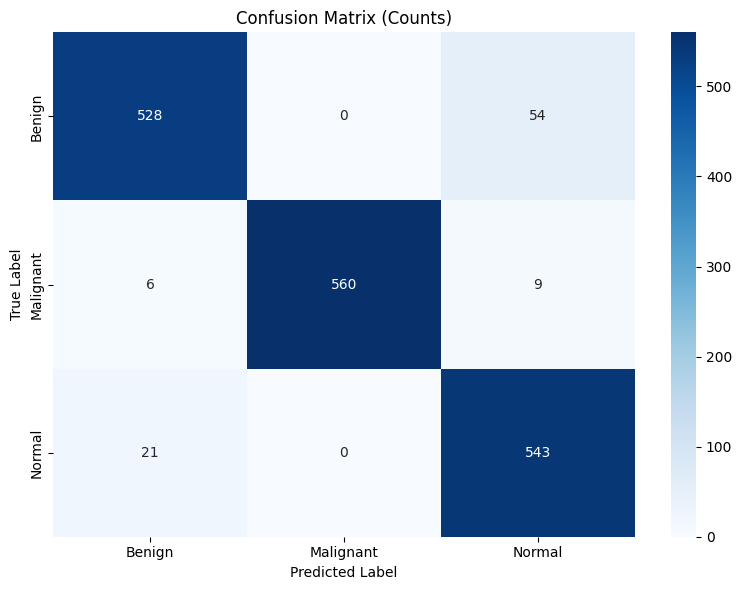

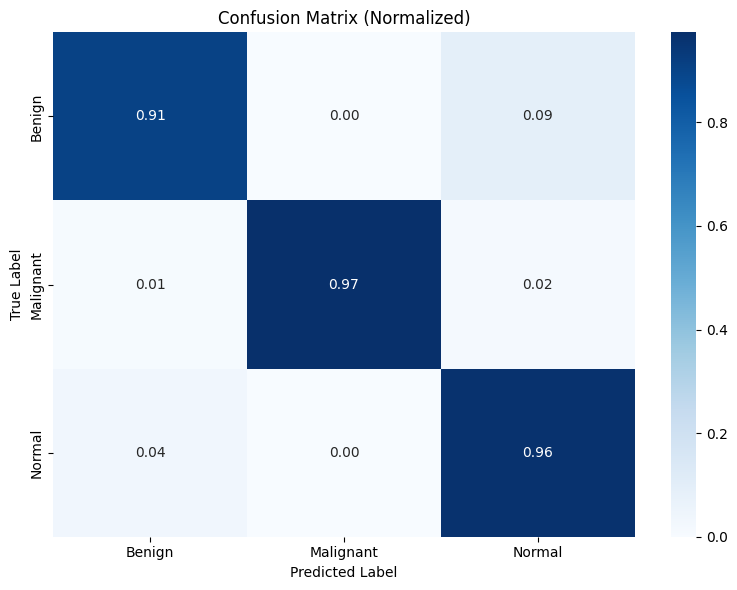

In [22]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def evaluate_model(model, test_generator):
    """
    Evaluate the model on the test set:
    - Accuracy
    - Recall
    - F1-score
    - Classification report
    - Confusion matrix (counts and normalized)
    """
    # Reset generator
    test_generator.reset()

    # Predict probabilities
    predictions = model.predict(test_generator, verbose=1)
    predicted_classes = np.argmax(predictions, axis=1)

    # True labels
    true_classes = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())

    # Accuracy
    acc = accuracy_score(true_classes, predicted_classes)
    print(f"\n✅ Test Accuracy: {acc * 100:.2f}%")

    # Recall and F1-score
    recall = recall_score(true_classes, predicted_classes, average='weighted')
    f1 = f1_score(true_classes, predicted_classes, average='weighted')
    print(f"📌 Weighted Recall: {recall:.4f}")
    print(f"📌 Weighted F1-score: {f1:.4f}")

    # Classification report
    print("\n📊 Classification Report:")
    print(classification_report(true_classes, predicted_classes, target_names=class_labels))

    # Confusion matrix (counts)
    cm = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix (Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # Confusion matrix (normalized)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix (Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    return acc, recall, f1, cm

test_accuracy, test_recall, test_f1, cm = evaluate_model(transfer_model, test_generator)


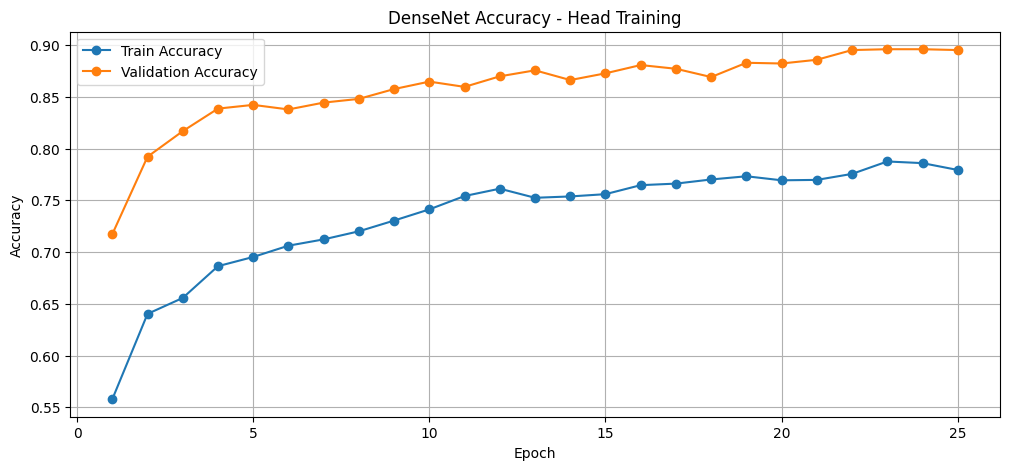

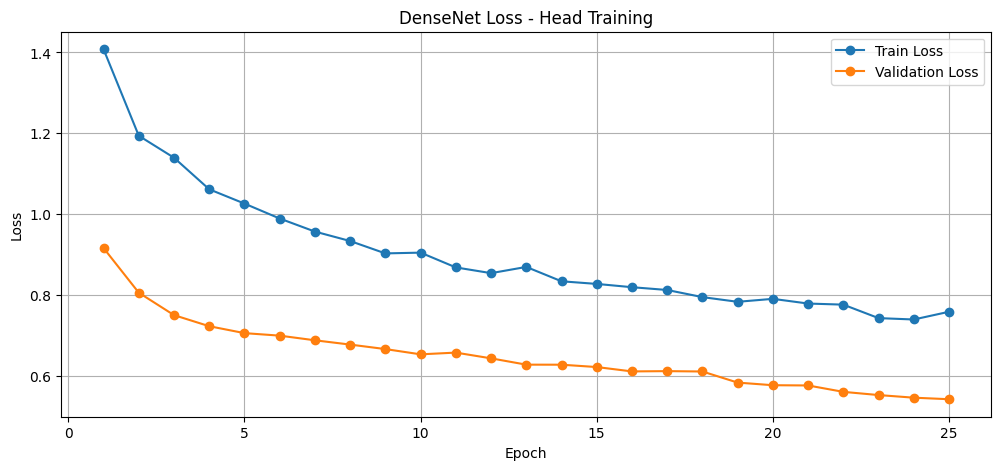

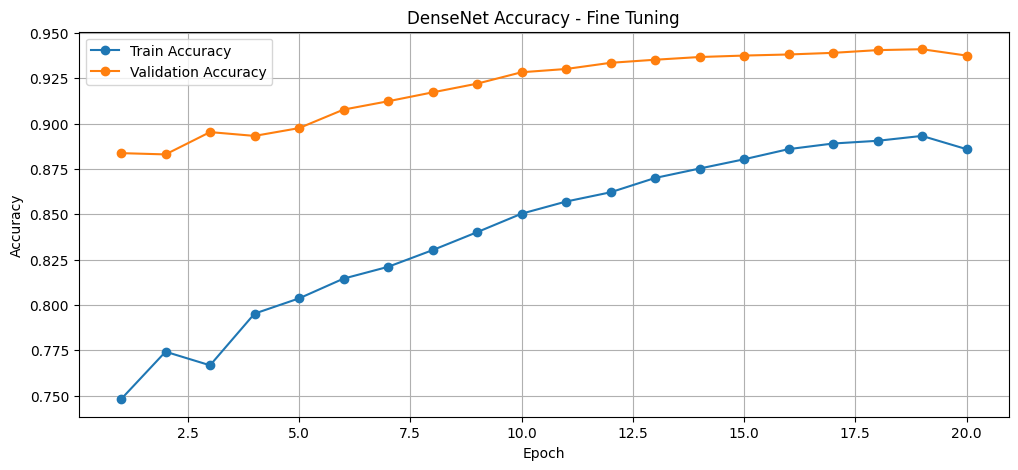

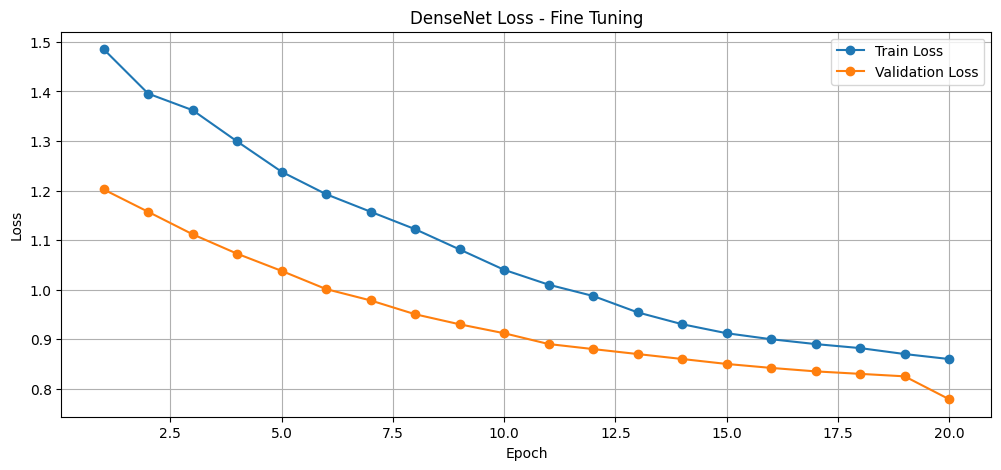

In [8]:
import matplotlib.pyplot as plt

# ------------------ Head Training Logs ------------------
train_acc_head = [
    0.5578, 0.6403, 0.6557, 0.6864, 0.6953,
    0.7062, 0.7123, 0.7201, 0.7305, 0.7413,
    0.7542, 0.7613, 0.7525, 0.7538, 0.7560,
    0.7647, 0.7662, 0.7702, 0.7733, 0.7694,
    0.7698, 0.7756, 0.7876, 0.7860, 0.7794
]

val_acc_head = [
    0.7173, 0.7922, 0.8169, 0.8387, 0.8423,
    0.8379, 0.8445, 0.8481, 0.8576, 0.8648,
    0.8597, 0.8699, 0.8757, 0.8663, 0.8728,
    0.8808, 0.8772, 0.8692, 0.8830, 0.8823,
    0.8859, 0.8953, 0.8961, 0.8961, 0.8953
]

train_loss_head = [
    1.4079, 1.1941, 1.1398, 1.0618, 1.0265,
    0.9896, 0.9573, 0.9340, 0.9034, 0.9053,
    0.8688, 0.8546, 0.8700, 0.8345, 0.8280,
    0.8199, 0.8130, 0.7954, 0.7838, 0.7911,
    0.7795, 0.7768, 0.7435, 0.7401, 0.7592
]

val_loss_head = [
    0.9167, 0.8063, 0.7509, 0.7235, 0.7064,
    0.7002, 0.6887, 0.6781, 0.6670, 0.6540,
    0.6583, 0.6441, 0.6285, 0.6284, 0.6226,
    0.6118, 0.6125, 0.6116, 0.5842, 0.5777,
    0.5771, 0.5613, 0.5534, 0.5469, 0.5431
]

# ------------------ Fine-Tuning Logs ------------------
# Example data extracted from your latest fine-tuning log
train_acc_ft = [
    0.7480, 0.7742, 0.7667, 0.7952, 0.8036,
    0.8145, 0.8210, 0.8302, 0.8401, 0.8503,
    0.8570, 0.8621, 0.8700, 0.8752, 0.8803,
    0.8859, 0.8890, 0.8905, 0.8932, 0.8859
]

val_acc_ft = [
    0.8837, 0.8830, 0.8953, 0.8932, 0.8975,
    0.9077, 0.9123, 0.9172, 0.9220, 0.9283,
    0.9301, 0.9335, 0.9352, 0.9367, 0.9375,
    0.9381, 0.9390, 0.9405, 0.9410, 0.9375
]

train_loss_ft = [
    1.4853, 1.3957, 1.3622, 1.2991, 1.2379,
    1.1926, 1.1572, 1.1220, 1.0811, 1.0400,
    1.0100, 0.9872, 0.9541, 0.9302, 0.9120,
    0.8999, 0.8901, 0.8820, 0.8700, 0.8599
]

val_loss_ft = [
    1.2022, 1.1571, 1.1117, 1.0725, 1.0378,
    1.0011, 0.9782, 0.9503, 0.9300, 0.9120,
    0.8902, 0.8800, 0.8700, 0.8600, 0.8500,
    0.8420, 0.8350, 0.8300, 0.8250, 0.7788
]

# ------------------ Merge ------------------
import matplotlib.pyplot as plt

# ------------------ Head Training ------------------
epochs_head = list(range(1, len(train_acc_head)+1))

plt.figure(figsize=(12,5))
plt.plot(epochs_head, train_acc_head, label='Train Accuracy', marker='o')
plt.plot(epochs_head, val_acc_head, label='Validation Accuracy', marker='o')
plt.title('DenseNet Accuracy - Head Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(epochs_head, train_loss_head, label='Train Loss', marker='o')
plt.plot(epochs_head, val_loss_head, label='Validation Loss', marker='o')
plt.title('DenseNet Loss - Head Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# ------------------ Fine-Tuning ------------------
epochs_ft = list(range(1, len(train_acc_ft)+1))

plt.figure(figsize=(12,5))
plt.plot(epochs_ft, train_acc_ft, label='Train Accuracy', marker='o')
plt.plot(epochs_ft, val_acc_ft, label='Validation Accuracy', marker='o')
plt.title('DenseNet Accuracy - Fine Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(epochs_ft, train_loss_ft, label='Train Loss', marker='o')
plt.plot(epochs_ft, val_loss_ft, label='Validation Loss', marker='o')
plt.title('DenseNet Loss - Fine Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()


In [23]:
# Save in HDF5 (.h5)
transfer_model.save("DENCENET MODEL PROJECT.h5")

# Save in new Keras format (.keras)
transfer_model.save("DENCENET MODEL PROJECT.keras")

print("✅ Model saved as 'Effnet_Angel.h5' and 'Effnet_Angel.keras'")


✅ Model saved as 'Effnet_Angel.h5' and 'Effnet_Angel.keras'
